# Results in the Schrodinger picture

Notebook to compute $\langle \delta p_i^2 \rangle = \langle (p_i - p_{i,0})^2 \rangle$ using the Schrodinger picture. We expand the fields at first order in $z$ so 
$$A_+(x^+, y, z) = \frac{1}{2} \left[ -\frac{z}{t} A_\eta(t, x=t, y) + A_x(t, x=t, y)\right]$$
and for the transverse fields $A_y(x^+, y, z) = A_y(t, x=t, y)$ and $A_z(x^+, y, z) =  A_\eta(t, x=t, y)/t$.

## 1. Results for $L=1\, \mathrm{fm}$

We fix a small lattice size $L=1\, \mathrm{fm}$ wich allows us to go to very fine lattices but at the cost of our results being sensitive to the lattice IR cutoff $\sim 1/L$. If we discover that we don't need such a fine lattices then one may expect the results to be also good for $L=5\, \mathrm{fm}$ where we are no longer sensitive to the lattice IR. We get results for $N= 128, 256, 512$

### Canonic momentum broeadening

We start computing this component

In [1]:
# We create a list with the files to read

Nevs = 50

p2_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/schrodinger_L=1_N=512/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/schrodinger_L=1_N=512/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

In [2]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

p2_df_list_128 = []; pp0_df_list_128 = []
p2_df_list_256 = []; pp0_df_list_256 = []
p2_df_list_512 = []; pp0_df_list_512 = []

for i in range(Nevs):
    p2_df_128 = [pd.read_table(p2_file_list_128[i], header = None)]
    pp0_df_128 = [pd.read_table(pp0_file_list_128[i], header = None)]
    
    p2_df_256 = [pd.read_table(p2_file_list_256[i], header = None)]
    pp0_df_256 = [pd.read_table(pp0_file_list_256[i], header = None)]
    
    p2_df_512 = [pd.read_table(p2_file_list_512[i], header = None)]
    pp0_df_512 = [pd.read_table(pp0_file_list_512[i], header = None)]
    
    p2_df_list_128.append(p2_df_128); pp0_df_list_128.append(pp0_df_128)
    p2_df_list_256.append(p2_df_256); pp0_df_list_256.append(pp0_df_256)
    p2_df_list_512.append(p2_df_512); pp0_df_list_512.append(pp0_df_512)

p2_data_128 = np.array(p2_df_list_128); pp0_data_128 = np.array(pp0_df_list_128)
p2_data_256 = np.array(p2_df_list_256); pp0_data_256 = np.array(pp0_df_list_256)
p2_data_512 = np.array(p2_df_list_512); pp0_data_512 = np.array(pp0_df_list_512)

In [3]:
# We average over color and events
p2_av_128 = np.average(p2_data_128, axis=(0, 1)); pp0_av_128 = np.average(pp0_data_128, axis=(0, 1))
p2_av_256 = np.average(p2_data_256, axis=(0, 1)); pp0_av_256 = np.average(pp0_data_256, axis=(0, 1))
p2_av_512 = np.average(p2_data_512, axis=(0, 1)); pp0_av_512 = np.average(pp0_data_512, axis=(0, 1))

In [4]:
# Take the different components of canonic momentum
xplus_128 = p2_av_128[:, 0]; xplus_256 = p2_av_256[:, 0]; xplus_512 = p2_av_512[:, 0]

p2_z_128 = p2_av_128[:, 1]; p2_z_256 = p2_av_256[:, 1]; p2_z_512 = p2_av_512[:, 1]
p2_y_128 = p2_av_128[:, 2]; p2_y_256 = p2_av_256[:, 2]; p2_y_512 = p2_av_512[:, 2]

pp0_z_128 = pp0_av_128[:, 1]; pp0_z_256 = pp0_av_256[:, 1]; pp0_z_512 = pp0_av_512[:, 1]
pp0_y_128 = pp0_av_128[:, 2]; pp0_y_256 = pp0_av_256[:, 2]; pp0_y_512 = pp0_av_512[:, 2]

In [5]:
# We compute momentum broadening
delta_p2_y_128 = p2_y_128 + p2_y_128[0] - pp0_y_128
delta_p2_z_128 = p2_z_128 + p2_z_128[0] - pp0_z_128

delta_p2_y_256 = p2_y_256 + p2_y_256[0] - pp0_y_256 
delta_p2_z_256 = p2_z_256 + p2_z_256[0] - pp0_z_256

delta_p2_y_512 = p2_y_512 + p2_y_512[0] - pp0_y_512
delta_p2_z_512 = p2_z_512 + p2_z_512[0] - pp0_z_512

### Field contribution

In [6]:
# We create a list with the files to read

Nevs = 50

A2_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/schrodinger_L=1_N=512/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/schrodinger_L=1_N=512/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

In [7]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

A2_df_list_128 = []; AA0_df_list_128 = []
A2_df_list_256 = []; AA0_df_list_256 = []
A2_df_list_512 = []; AA0_df_list_512 = []

for i in range(Nevs):
    A2_df_128 = [pd.read_table(A2_file_list_128[i], header = None)]
    AA0_df_128 = [pd.read_table(AA0_file_list_128[i], header = None)]
    
    A2_df_256 = [pd.read_table(A2_file_list_256[i], header = None)]
    AA0_df_256 = [pd.read_table(AA0_file_list_256[i], header = None)]
    
    A2_df_512 = [pd.read_table(A2_file_list_512[i], header = None)]
    AA0_df_512 = [pd.read_table(AA0_file_list_512[i], header = None)]

    A2_df_list_128.append(A2_df_128); AA0_df_list_128.append(AA0_df_128)
    A2_df_list_256.append(A2_df_256); AA0_df_list_256.append(AA0_df_256)
    A2_df_list_512.append(A2_df_512); AA0_df_list_512.append(AA0_df_512)

A2_data_128 = np.array(A2_df_list_128);AA0_data_128 = np.array(AA0_df_list_128)
A2_data_256 = np.array(A2_df_list_256);AA0_data_256 = np.array(AA0_df_list_256)
A2_data_512 = np.array(A2_df_list_512);AA0_data_512 = np.array(AA0_df_list_512)

In [8]:
# We average over color and events
A2_av_128 = np.average(A2_data_128, axis=(0, 1)); AA0_av_128 = np.average(AA0_data_128, axis=(0, 1))
A2_av_256 = np.average(A2_data_256, axis=(0, 1)); AA0_av_256 = np.average(AA0_data_256, axis=(0, 1))
A2_av_512 = np.average(A2_data_512, axis=(0, 1)); AA0_av_512 = np.average(AA0_data_512, axis=(0, 1))

In [9]:
# Take the different components of canonic momentum
xplus_128 = A2_av_128[:, 0]; xplus_256 = A2_av_256[:, 0]; xplus_512 = A2_av_512[:, 0]

A2_z_128 = A2_av_128[:, 2]; A2_z_256 = A2_av_256[:, 2]; A2_z_512 = A2_av_512[:, 2]
A2_y_128 = A2_av_128[:, 6]; A2_y_256 = A2_av_256[:, 6]; A2_y_512 = A2_av_512[:, 6]

AA0_z_128 = AA0_av_128[:, 1]; AA0_z_256 = AA0_av_256[:, 1]; AA0_z_512 = AA0_av_512[:, 1]
AA0_y_128 = AA0_av_128[:, 2]; AA0_y_256 = AA0_av_256[:, 2]; AA0_y_512 = AA0_av_512[:, 2]

In [10]:
# We compute momentum broadening
delta_A2_y_128 = A2_y_128 + A2_y_128[0] -  AA0_y_128
delta_A2_z_128 = A2_z_128 + A2_z_128[0] - AA0_z_128

delta_A2_y_256 = A2_y_256 + A2_y_256[0] -  AA0_y_256
delta_A2_z_256 = A2_z_256 + A2_z_256[0] - AA0_z_256

delta_A2_y_512 = A2_y_512 + A2_y_512[0] -  AA0_y_512
delta_A2_z_512 = A2_z_512 + A2_z_512[0] - AA0_z_512

### Cross terms

In [11]:
# We create a list with the files to read

Nevs = 50

pA_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]
p0A_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/schrodinger_L=1_N=512/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/schrodinger_L=1_N=512/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/schrodinger_L=1_N=512/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

In [12]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

pA_df_list_128 = []; pA0_df_list_128 = []; p0A_df_list_128 = []
pA_df_list_256 = []; pA0_df_list_256 = []; p0A_df_list_256 = []
pA_df_list_512 = []; pA0_df_list_512 = []; p0A_df_list_512 = []

for i in range(Nevs):
    pA_df_128 = [pd.read_table(pA_file_list_128[i], header = None)]
    pA0_df_128 = [pd.read_table(pA0_file_list_128[i], header = None)]
    p0A_df_128 = [pd.read_table(p0A_file_list_128[i], header = None)]
    
    pA_df_256 = [pd.read_table(pA_file_list_256[i], header = None)]
    pA0_df_256 = [pd.read_table(pA0_file_list_256[i], header = None)]
    p0A_df_256 = [pd.read_table(p0A_file_list_256[i], header = None)]
    
    pA_df_512 = [pd.read_table(pA_file_list_512[i], header = None)]
    pA0_df_512 = [pd.read_table(pA0_file_list_512[i], header = None)]
    p0A_df_512 = [pd.read_table(p0A_file_list_512[i], header = None)]

    pA_df_list_128.append(pA_df_128); pA0_df_list_128.append(pA0_df_128); p0A_df_list_128.append(p0A_df_128)
    pA_df_list_256.append(pA_df_256); pA0_df_list_256.append(pA0_df_256); p0A_df_list_256.append(p0A_df_256)
    pA_df_list_512.append(pA_df_512); pA0_df_list_512.append(pA0_df_512); p0A_df_list_512.append(p0A_df_512)

pA_data_128 = np.array(pA_df_list_128); pA0_data_128 = np.array(pA0_df_list_128); p0A_data_128 = np.array(p0A_df_list_128)
pA_data_256 = np.array(pA_df_list_256); pA0_data_256 = np.array(pA0_df_list_256); p0A_data_256 = np.array(p0A_df_list_256)
pA_data_512 = np.array(pA_df_list_512); pA0_data_512 = np.array(pA0_df_list_512); p0A_data_512 = np.array(p0A_df_list_512)

In [13]:
# We average over color and events
pA_av_128 = np.average(pA_data_128, axis=(0, 1)); pA0_av_128 = np.average(pA0_data_128, axis=(0, 1)); p0A_av_128 = np.average(p0A_data_128, axis=(0, 1))
pA_av_256 = np.average(pA_data_256, axis=(0, 1)); pA0_av_256 = np.average(pA0_data_256, axis=(0, 1)); p0A_av_256 = np.average(p0A_data_256, axis=(0, 1))
pA_av_512 = np.average(pA_data_512, axis=(0, 1)); pA0_av_512 = np.average(pA0_data_512, axis=(0, 1)); p0A_av_512 = np.average(p0A_data_512, axis=(0, 1))

In [14]:
# Take the different components of canonic momentum
xplus_128 = pA_av_128[:, 0]; xplus_256 = pA_av_256[:, 0]; xplus_512 = pA_av_512[:, 0]

pA_z_128 = pA_av_128[:, 3]; pA_z_256 = pA_av_256[:, 3]; pA_z_512 = pA_av_512[:, 3]
pA_y_128 = pA_av_128[:, 7]; pA_y_256 = pA_av_256[:, 7]; pA_y_512 = pA_av_512[:, 7]

pA0_z_128 = pA0_av_128[:, 1]; pA0_z_256 = pA0_av_256[:, 1]; pA0_z_512 = pA0_av_512[:, 1]
pA0_y_128 = pA0_av_128[:, 2]; pA0_y_256 = pA0_av_256[:, 2]; pA0_y_512 = pA0_av_512[:, 2]

p0A_z_128 = p0A_av_128[:, 1]; p0A_z_256 = p0A_av_256[:, 1]; p0A_z_512 = p0A_av_512[:, 1]
p0A_y_128 = p0A_av_128[:, 2]; p0A_y_256 = p0A_av_256[:, 2]; p0A_y_512 = p0A_av_512[:, 2]

In [15]:
# We compute momentum broadening
delta_pA_y_128 = pA_y_128 + pA_y_128[0] -  pA0_y_128 - p0A_y_128
delta_pA_z_128 = pA_z_128 + pA_z_128[0] -  pA0_z_128 - p0A_z_128

delta_pA_y_256 = pA_y_256 + pA_y_256[0] -  pA0_y_256 - p0A_y_256
delta_pA_z_256 = pA_z_256 + pA_z_256[0] -  pA0_z_256 - p0A_z_256

delta_pA_y_512 = pA_y_512 + pA_y_512[0] -  pA0_y_512 - p0A_y_512
delta_pA_z_512 = pA_z_512 + pA_z_512[0] -  pA0_z_512 - p0A_z_512

### Kinetic momentum

In [16]:
# We compute the quantum result

delta_pkin_y2_128 = delta_p2_y_128 + delta_A2_y_128 + delta_pA_y_128
delta_pkin_z2_128 = delta_p2_z_128 + delta_A2_z_128 + delta_pA_z_128

delta_pkin_y2_256 = delta_p2_y_256 + delta_A2_y_256 + delta_pA_y_256
delta_pkin_z2_256 = delta_p2_z_256 + delta_A2_z_256 + delta_pA_z_256

delta_pkin_y2_512 = delta_p2_y_512 + delta_A2_y_512 + delta_pA_y_512
delta_pkin_z2_512 = delta_p2_z_512 + delta_A2_z_512 + delta_pA_z_512

In [17]:
# We load the classical result

xp_class = np.loadtxt('classical_results_L=1/classical_pi.txt')[0]
delta_pkin_y2_class = np.loadtxt('classical_results_L=1/classical_pi.txt')[1]
delta_pkin_z2_class = np.loadtxt('classical_results_L=1/classical_pi.txt')[2]

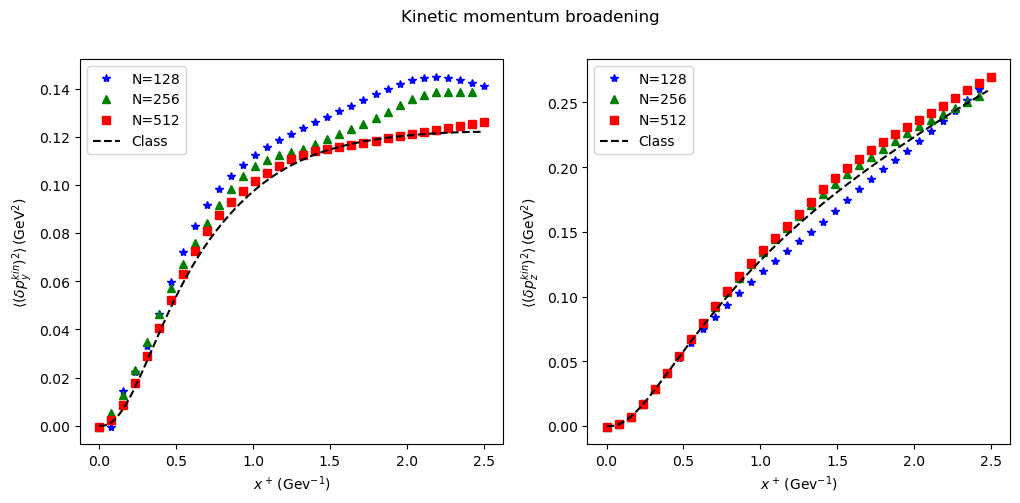

In [18]:
# We plot the results

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(xplus_128+1/(128*0.2)*2, delta_pkin_y2_128, '*', label='N=128', color='blue')
axes[0].plot(xplus_256, delta_pkin_y2_256, '^', label='N=256', color='green')
axes[0].plot(xplus_512, delta_pkin_y2_512, 's', label='N=512', color='red')
axes[0].plot(xp_class*2/0.2, delta_pkin_y2_class/3, label='Class', color='black', linestyle='--')
axes[0].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[0].set_ylabel(r'$\langle (\delta p^{kin}_y)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[0].legend()

axes[1].plot(xplus_128, delta_pkin_z2_128, '*', label='N=128', color='blue')
axes[1].plot(xplus_256, delta_pkin_z2_256, '^', label='N=256', color='green')
axes[1].plot(xplus_512, delta_pkin_z2_512, 's', label='N=512', color='red')
axes[1].plot(xp_class*2/0.2, delta_pkin_z2_class/3, label='Class', color='black', linestyle='--')
axes[1].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[1].set_ylabel(r'$\langle (\delta p^{kin}_z)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[1].legend()

fig.suptitle('Kinetic momentum broadening')
plt.show()

fig.savefig('L=1_plots/Kinetic_momentum_broadening.png', bbox_inches='tight')